![logo](./img/LogoLine_horizon_C3S.png)

## Getting and plotting 2m temperatuere from CARRA

CARRA data can be found in the CDS (Copernicus Climate Data Store, https://cds.climate.copernicus.eu/cdsapp#!/home).
The CARRA entry is https://cds.climate.copernicus.eu/cdsapp#!/search?text=CARRA.
Here the single levels are chosen to limit the size of the data.
You need to create an account and accept the terms and conditions for all datasets that you want to use.


### Fetching CARRA data
The source code will download a specific month. By specifying the start and end date below one can easily download longer periods. We are selecting 2m temperature and single levels. 
Here, we download the 3-hourly analysis time steps and the data will be stored in a specified file.

![logo](./img/climatology_banner.png)

<style>
td, th {
   border: 1px solid white;
   border-collapse: collapse;
}
</style>
<table align="left">
  <tr>
    <th>
      To run the notebooks in the cloud environment click on the icons for "binder" or "kaggle" or "colab" in the menubar below.<br><br>
      <div>
        <a href="https://mybinder.org/v2/gh/ecmwf-projects/copernicus-training-c3s/main?labpath=reanalysis-climatology.ipynb">
          <img src="https://mybinder.org/badge.svg" alt="Binder">
        </a>
        <a href="https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-projects/copernicus-training-c3s/blob/main/reanalysis-climatology.ipynb">
          <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Kaggle">
        </a>
        <a href="https://colab.research.google.com/github/ecmwf-projects/copernicus-training-c3s/blob/main/reanalysis-climatology.ipynb">
          <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Colab">
        </a>
      </div>
    </th>
  </tr>
</table>


In [7]:
import os
import cdsapi
import warnings
warnings.filterwarnings('ignore') #turn off some warnings
import cdsapi
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
# Here one specifies the domain, year and period to download

yearStart = 2024 #first year to download
yearEnd   = 2024 #last year to download
monthStart =  3 # first month to download
monthEnd   =  3 #last month to download
days = [str(i).zfill(2) for i in range(1,31)] # the list of days to download. Adapt day number for other months
domain = 'west_domain' # the domain to select. Use "east_domain" for the East domain
# the local directory where the data will be stored
DATADIR="CARRA"
#Below a polygon to limit the area downloaded from ERA5, otherwise it will download the whole world
area_for_era5 = [90, -110, 55, 40] #west domain polygon, format: North,West,South,East corners
#area_for_era5 = [85,0,60,50]: east domain polygon
        

---

In [3]:

# create directory to store CARRA data if it does not exist already:
if not os.path.isdir(DATADIR):
    os.makedirs(os.path.join(DATADIR,"Raw_data"))
c = cdsapi.Client()

# define a helper function to download the data
# Note that the time is hardcoded since we are selecting
# all possible available times. 
def fetch_one_month(month, year, days, domain):
    c.retrieve(
        'reanalysis-carra-single-levels',
        {
            'format': 'grib',
            'domain': domain ,
            'level_type': 'surface_or_atmosphere',
            'variable': '2m_temperature',
            'product_type': 'analysis',
            'year': year,
            'month': month,
            'day': days,
            'time': [
                '00:00', '03:00', '06:00',
                '09:00', '12:00', '15:00',
                '18:00', '21:00',
            ],
        },
        os.path.join(DATADIR,"Raw_data",'T2m_an_'+str(year)+"{:02d}".format(month)+'.grb'))

    



In [4]:
# Loop through the period selected
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("Data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (~621 MB for west, ~357 MB for east case)")
        fetch_one_month(month, year, days, domain)

Data will be fetched for  2024 3
This will take a few minutes, depending on the data size (~621 MB for west, ~357 MB for east case)


2024-07-05 13:10:05,939 INFO Welcome to the CDS
2024-07-05 13:10:05,940 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-carra-single-levels
2024-07-05 13:10:06,391 INFO Request is queued
2024-07-05 13:10:19,877 INFO Request is running
2024-07-05 13:10:38,988 INFO Request is completed
2024-07-05 13:10:38,989 INFO Downloading https://download-0004-clone.copernicus-climate.eu/cache-compute-0004/cache/data1/adaptor.mars.external-1720177819.633887-6195-2-1a3b91dc-c725-4db8-bcdf-f4c61e27f33b.grib to CARRA/Raw_data/T2m_an_202403.grb (621.2M)
2024-07-05 13:12:26,403 INFO Download rate 5.8M/s                                                                                                                                     


## Plotting the data
Compute the mean 2m temperature over the whole month and plott it on a map.

In [5]:

period="202403" # the period to plot
fCARRA = os.path.join(DATADIR,"Raw_data","T2m_an_"+period+".grb")
import xarray as xr

# Open Datasets
CARRA = xr.open_dataset(fCARRA)

# Compute monthly mean
print("Compute the mean")
CARRA_mean = CARRA.mean(dim="time", keep_attrs=True)
# Change longitudes from 0-360 to -180 to 180, needed for the plotting
CARRA_mean = CARRA_mean.assign_coords(longitude=(((CARRA_mean.longitude + 180) % 360) - 180))

# Change unit from K to C and add the unit to the attributes
CARRA_mean_C = CARRA_mean - 273.15
CARRA_mean_C = CARRA_mean_C.assign_attrs(CARRA_mean.attrs)
CARRA_mean_C.attrs['units'] = 'deg C'

print("Done.")


Ignoring index file 'CARRA/Raw_data/T2m_an_202403.grb.923a8.idx' older than GRIB file


Compute the mean
Done.


Plotting CARRA


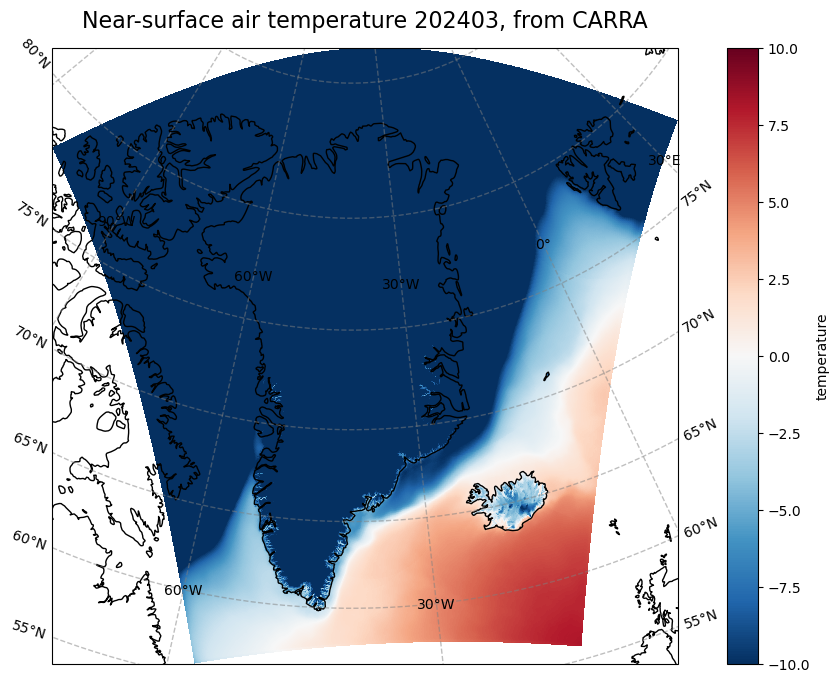

In [9]:
print("Plotting CARRA")
# create the figure panel and the map using the Cartopy Lambert conformal projection
fig, ax = plt.subplots(1, 1, figsize = (16, 8), subplot_kw={'projection': ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0)})

# Plot the data, the differences are computed on the fly.
im = plt.pcolormesh(CARRA_mean_C.longitude, CARRA_mean_C.latitude,CARRA_mean_C.t2m,
                    transform = ccrs.PlateCarree(), cmap='RdBu_r', vmin=-10, vmax=10)

# Set the figure title
ax.set_title('Near-surface air temperature '+period+', from CARRA', fontsize=16)
ax.coastlines(color='black')
ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--') 

# Specify the colourbar
cbar = plt.colorbar(im,fraction=0.05, pad=0.04)
cbar.set_label('temperature')

# Save the figure
fig.savefig(f'{DATADIR}/Figures/CARRA_T2m_map.png')

---

In [9]:
DATADIR=os.path.join("CARRA","ERA5") 
# create the directory where the data will be stored if it does not exist already

if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
    
# Help function to download ERA5 data
def fetch_month_era5(month, year, days, area):
    c.retrieve(
    'reanalysis-era5-single-levels',
    {
        'product_type': 'reanalysis',
        'variable': '2m_temperature',
        'year': str(year),
        'month': str(month).zfill(2),
        'day': days,
        'time': [
            '00:00', '03:00', '06:00',
            '09:00', '12:00', '15:00',
            '18:00', '21:00',
        ],
        'area': area,
        'format': 'netcdf',
    },
     os.path.join(DATADIR,'era5_t2m_'+str(year)+"{:02d}".format(month)+'.grb'))
    
# Loop through the period selected
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("ERA5 data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (~39 MB for west area)")
        fetch_month_era5(month, year, days, area_for_era5)

2024-06-05 19:48:13,668 INFO Welcome to the CDS
2024-06-05 19:48:13,669 INFO Sending request to https://cds.climate.copernicus.eu/api/v2/resources/reanalysis-era5-single-levels
2024-06-05 19:48:13,787 INFO Downloading https://download-0016.copernicus-climate.eu/cache-compute-0016/cache/data8/adaptor.mars.internal-1717608329.8119001-29397-4-04898c6c-c581-4d76-b847-9c47bcf39051.nc to CARRA/ERA5/era5_t2m_202403.grb (38.8M)


ERA5 data will be fetched for  2024 3
This will take a few minutes, depending on the data size (~39 MB for west area)


2024-06-05 19:48:25,849 INFO Download rate 3.2M/s                                                                                            
